# Comprehensive Model Evaluation

## Federated Intrusion Detection System Assessment

### Overview

This notebook provides a comprehensive evaluation of the federated intrusion detection system developed for the SWaT industrial water treatment dataset. The evaluation covers:

- **Model Performance**: ROC curves, precision-recall analysis, confusion matrices
- **Temporal Analysis**: Attack detection timelines and probability trends
- **Feature Importance**: Sensor contributions to intrusion detection
- **Comparative Analysis**: Edge nodes vs global federated models
- **Reliability Assessment**: False positive/negative rates for industrial deployment

### Models Evaluated

1. **Edge Node Models** (6 individual models)
   - Trained on local sensor subsets
   - Represent distributed edge computing

2. **FedAvg Global Model**
   - Standard federated averaging
   - Equal weighting of all edge nodes

3. **Adaptive AFEL Model**
   - Performance-based weighted aggregation
   - Prioritizes high-performing edge nodes

### Evaluation Metrics

- **ROC-AUC**: Overall classification performance
- **Precision-Recall**: Attack detection quality (important for imbalanced data)
- **Confusion Matrix**: False positive/negative analysis
- **Temporal Performance**: Detection speed and consistency
- **Feature Attribution**: Sensor importance for explainability

### Industrial Relevance

This evaluation assesses the system's suitability for:
- **Critical Infrastructure Protection**: Water treatment, manufacturing
- **Real-time Monitoring**: Edge deployment constraints
- **Privacy Compliance**: Federated learning without data sharing
- **Operational Reliability**: Low false positive rates for alerts

## Import Required Libraries

In [5]:
import pandas as pd
import numpy as np
import joblib
import os

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries loaded successfully")

Libraries loaded successfully


## Load Trained Models

In [6]:
DATA_PATH = r"C:\Adaptive_Federated_Water_IoT\data\raw\merged.csv"

EDGE_MODEL_PATH = r"C:\Adaptive_Federated_Water_IoT\notebooks\models"

RESULT_FIG_PATH = r"C:\Adaptive_Federated_Water_IoT\results\figures"
RESULT_STAT_PATH = r"C:\Adaptive_Federated_Water_IoT\results\statistics"

os.makedirs(RESULT_FIG_PATH, exist_ok=True)
os.makedirs(RESULT_STAT_PATH, exist_ok=True)

print("Paths configured")

Paths configured


## Load Test Dataset

In [7]:
print("Loading merged dataset")

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

timestamp_col = "Timestamp"
label_col = "Normal/Attack"

timestamps = pd.to_datetime(df[timestamp_col], errors="coerce")

X = df.drop([timestamp_col, label_col], axis=1).astype(float)
y = (df[label_col].str.lower() != "normal").astype(int)

print("Dataset loaded")
print("Samples:", len(df))
print("Features:", X.shape[1])
print("Attack ratio:", y.mean())

Loading merged dataset


C:\Users\Latha E\AppData\Local\Temp\ipykernel_41120\3940749471.py:9: UserWarning: Parsing dates in  %d/%m/%Y %I:%M:%S %p format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  timestamps = pd.to_datetime(df[timestamp_col], errors="coerce")


Dataset loaded
Samples: 1441719
Features: 51
Attack ratio: 0.037886023559375995


## Train/Test Split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, ts_train, ts_test = train_test_split(
    X,
    y,
    timestamps,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Test samples:", len(X_test))
print("Attack samples in test:", sum(y_test))

Test samples: 288344
Attack samples in test: 10924


## Load Models

In [9]:
print("Loading trained models")

edge_nodes = [
    "Edge_Node_1",
    "Edge_Node_2",
    "Edge_Node_3",
    "Edge_Node_4",
    "Edge_Node_5",
    "Edge_Node_6"
]

edge_models = {}

for node in edge_nodes:
    path = f"{EDGE_MODEL_PATH}\\{node}_model.pkl"
    
    if os.path.exists(path):
        edge_models[node] = joblib.load(path)
        print(node, "loaded")
    else:
        print(node, "missing")

# Global models

fedavg_model = None
afel_model = None

fed_path = f"{EDGE_MODEL_PATH}\\fedavg_global_model.pkl"
afel_path = f"{EDGE_MODEL_PATH}\\adaptive_afel_model.pkl"

if os.path.exists(fed_path):
    fedavg_model = joblib.load(fed_path)
    print("FedAvg model loaded")

if os.path.exists(afel_path):
    afel_model = joblib.load(afel_path)
    print("Adaptive AFEL model loaded")

Loading trained models
Edge_Node_1 loaded
Edge_Node_2 loaded
Edge_Node_3 loaded
Edge_Node_4 loaded
Edge_Node_5 loaded
Edge_Node_6 loaded
FedAvg model loaded
Adaptive AFEL model loaded


## ROC Curve Analysis

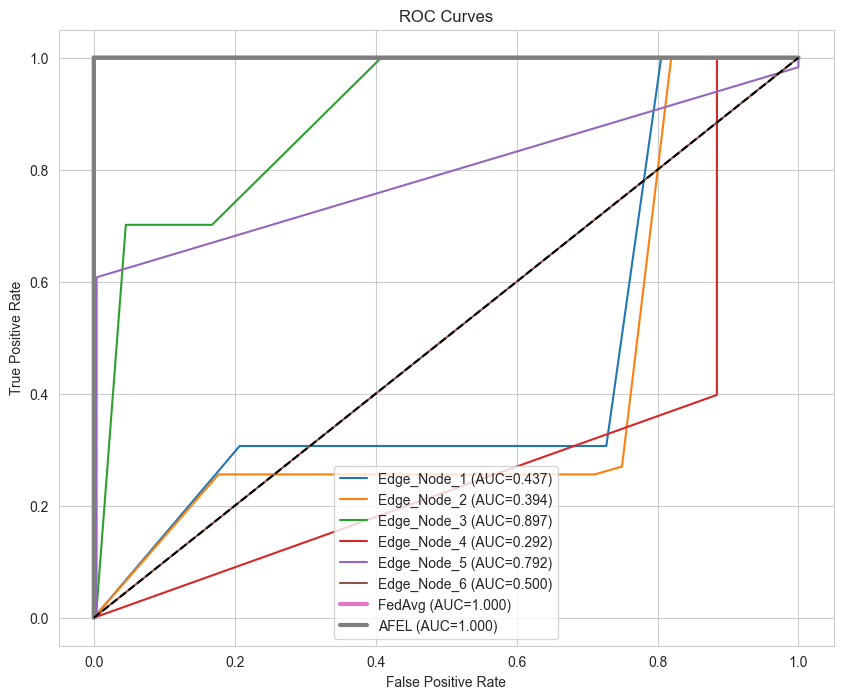

In [11]:
plt.figure(figsize=(10,8))

roc_results = {}

for node, model in edge_models.items():

    if model is None:
        continue

    # Get the features used during training
    features = model.feature_names_in_

    # Select only those columns
    X_edge = X_test[features]

    # Predict probabilities
    y_prob = model.predict_proba(X_edge)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr,tpr)

    roc_results[node] = roc_auc

    plt.plot(fpr,tpr,label=f"{node} (AUC={roc_auc:.3f})")


# FedAvg model
if fedavg_model is not None:

    y_prob = fedavg_model.predict_proba(X_test)[:,1]

    fpr,tpr,_ = roc_curve(y_test,y_prob)
    roc_auc = auc(fpr,tpr)

    plt.plot(fpr,tpr,linewidth=3,label=f"FedAvg (AUC={roc_auc:.3f})")


# AFEL model
if afel_model is not None:

    features = afel_model.feature_names_in_

    X_afel = X_test[features]

    y_prob = afel_model.predict_proba(X_afel)[:,1]

    fpr,tpr,_ = roc_curve(y_test,y_prob)
    roc_auc = auc(fpr,tpr)

    plt.plot(fpr,tpr,linewidth=3,label=f"AFEL (AUC={roc_auc:.3f})")


plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.savefig(f"{RESULT_FIG_PATH}\\roc_curves.png",dpi=300)

plt.show()

## Precision Recall Curves

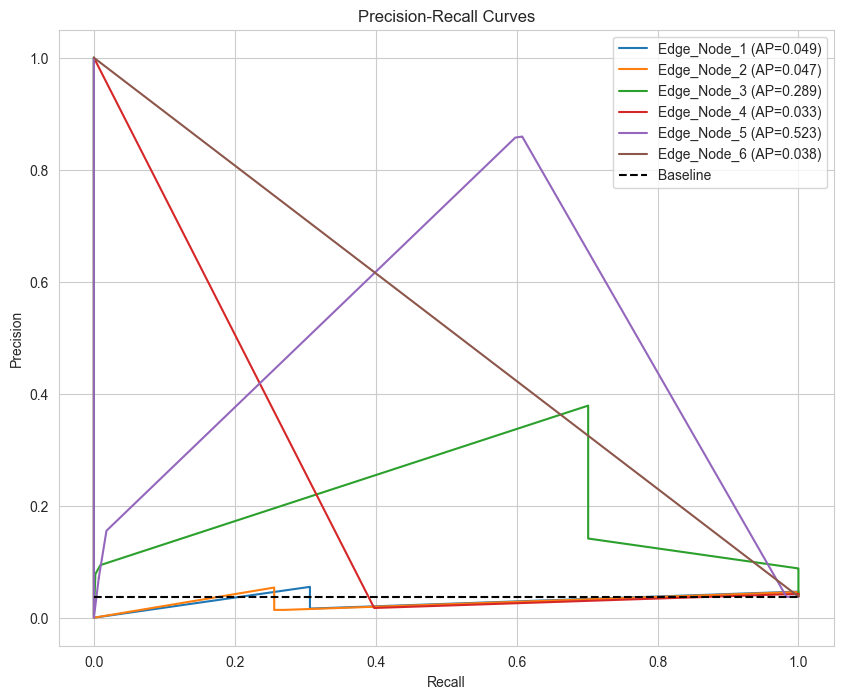

In [13]:
plt.figure(figsize=(10,8))

for node, model in edge_models.items():

    if model is None:
        continue

    # Get the features used during training
    features = model.feature_names_in_

    # Select only those features
    X_edge = X_test[features]

    # Predict probabilities
    y_prob = model.predict_proba(X_edge)[:,1]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    ap = average_precision_score(y_test, y_prob)

    plt.plot(recall, precision, label=f"{node} (AP={ap:.3f})")


# Baseline
baseline = y_test.mean()

plt.plot([0,1],[baseline,baseline],'k--',label="Baseline")

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curves")

plt.legend()

plt.savefig(f"{RESULT_FIG_PATH}\\precision_recall_curves.png",dpi=300)

plt.show()

## Confusion Matrices

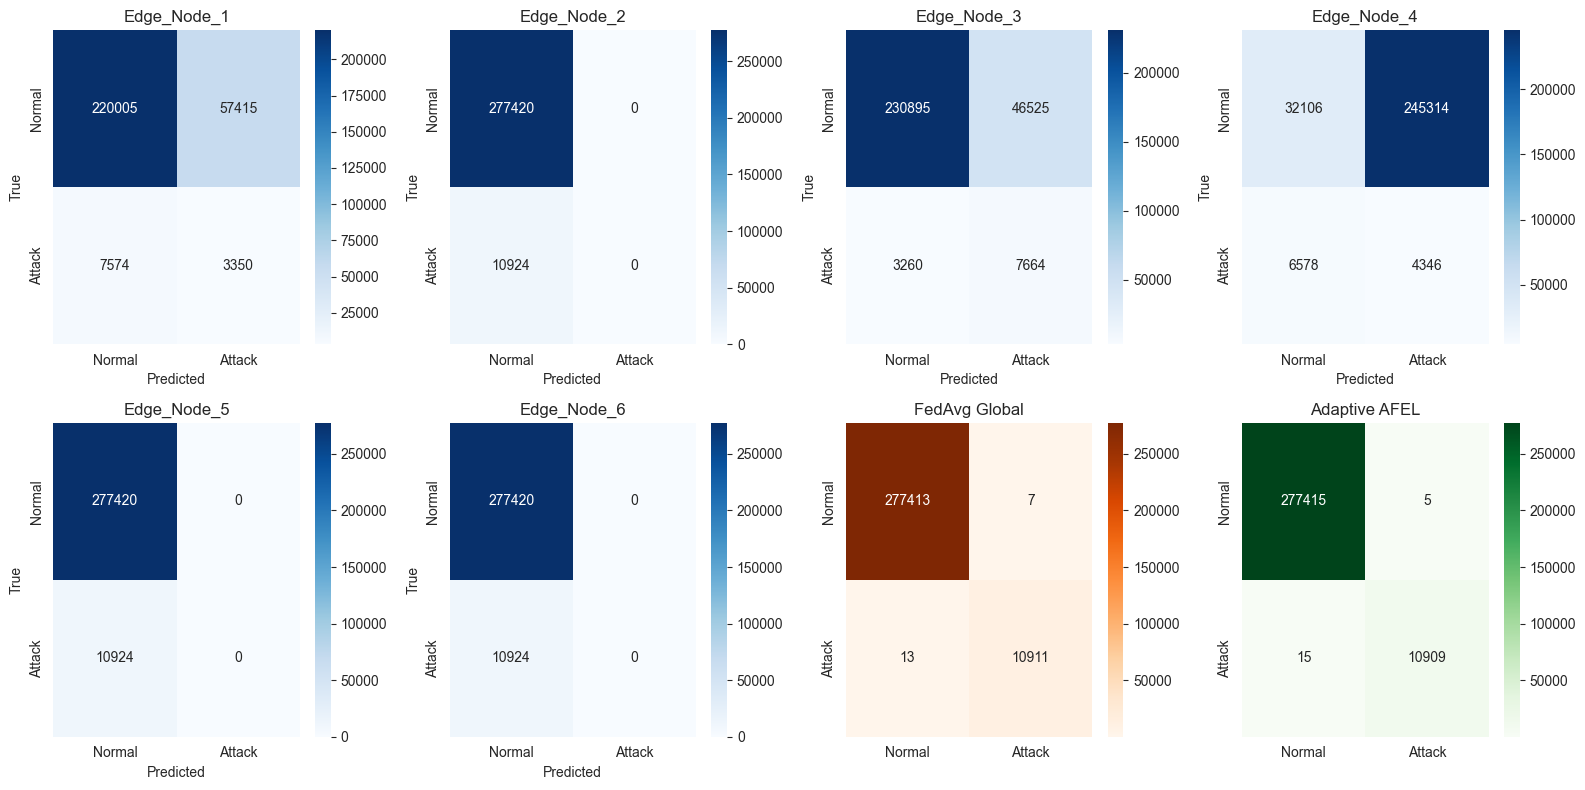

In [17]:
fig, axes = plt.subplots(2,4,figsize=(16,8))
axes = axes.ravel()

i = 0

for node, model in edge_models.items():

    if model is None:
        axes[i].axis("off")
        i += 1
        continue

    # IMPORTANT: use only features used during training
    features = model.feature_names_in_
    X_model = X_test[features]

    y_pred = model.predict(X_model)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap="Blues",
        ax=axes[i],
        xticklabels=["Normal","Attack"],
        yticklabels=["Normal","Attack"]
    )

    axes[i].set_title(node)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")

    i += 1


# FedAvg model (uses ALL sensors)
if fedavg_model is not None:

    y_pred = fedavg_model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap="Oranges",
        ax=axes[6],
        xticklabels=["Normal","Attack"],
        yticklabels=["Normal","Attack"]
    )

    axes[6].set_title("FedAvg Global")

else:
    axes[6].axis("off")


# AFEL model
if afel_model is not None:

    features = afel_model.feature_names_in_
    X_model = X_test[features]

    y_pred = afel_model.predict(X_model)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap="Greens",
        ax=axes[7],
        xticklabels=["Normal","Attack"],
        yticklabels=["Normal","Attack"]
    )

    axes[7].set_title("Adaptive AFEL")

else:
    axes[7].axis("off")


plt.tight_layout()

plt.savefig(f"{RESULT_FIG_PATH}\\confusion_matrices.png",dpi=300)

plt.show()

## False positive / False Negative Rates

In [18]:
print("\nError Rates\n")

for node, model in edge_models.items():

    if model is None:
        continue

    features = model.feature_names_in_

    X_model = X_test[features]

    y_pred = model.predict(X_model)

    tn,fp,fn,tp = confusion_matrix(y_test,y_pred).ravel()

    fpr = fp/(fp+tn)

    fnr = fn/(fn+tp)

    print(node,"| FPR:",round(fpr,4),"| FNR:",round(fnr,4))


Error Rates

Edge_Node_1 | FPR: 0.207 | FNR: 0.6933
Edge_Node_2 | FPR: 0.0 | FNR: 1.0
Edge_Node_3 | FPR: 0.1677 | FNR: 0.2984
Edge_Node_4 | FPR: 0.8843 | FNR: 0.6022
Edge_Node_5 | FPR: 0.0 | FNR: 1.0
Edge_Node_6 | FPR: 0.0 | FNR: 1.0


## Model Comparison Table

In [19]:
results = []

for node, model in edge_models.items():

    if model is None:
        continue

    features = model.feature_names_in_

    X_model = X_test[features]

    y_pred = model.predict(X_model)

    results.append({
        "Model":node,
        "Accuracy":accuracy_score(y_test,y_pred),
        "Precision":precision_score(y_test,y_pred),
        "Recall":recall_score(y_test,y_pred),
        "F1":f1_score(y_test,y_pred)
    })


if fedavg_model is not None:

    y_pred = fedavg_model.predict(X_test)

    results.append({
        "Model":"FedAvg",
        "Accuracy":accuracy_score(y_test,y_pred),
        "Precision":precision_score(y_test,y_pred),
        "Recall":recall_score(y_test,y_pred),
        "F1":f1_score(y_test,y_pred)
    })


results_df = pd.DataFrame(results)

results_df.to_csv(f"{RESULT_STAT_PATH}\\model_comparison.csv",index=False)

results_df

C:\Users\Latha E\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Latha E\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Latha E\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

,Model,Accuracy,Precision,Recall,F1
0,Edge_Node_1,0.774613,0.055130,0.306664,0.093459
1,Edge_Node_2,0.962115,0.000000,0.000000,0.000000
2,Edge_Node_3,0.827342,0.141431,0.701575,0.235406
3,Edge_Node_4,0.126418,0.017408,0.397840,0.033356
4,Edge_Node_5,0.962115,0.000000,0.000000,0.000000
5,Edge_Node_6,0.962115,0.000000,0.000000,0.000000
6,FedAvg,0.999931,0.999359,0.998810,0.999084


## Attack Timeline Visualization

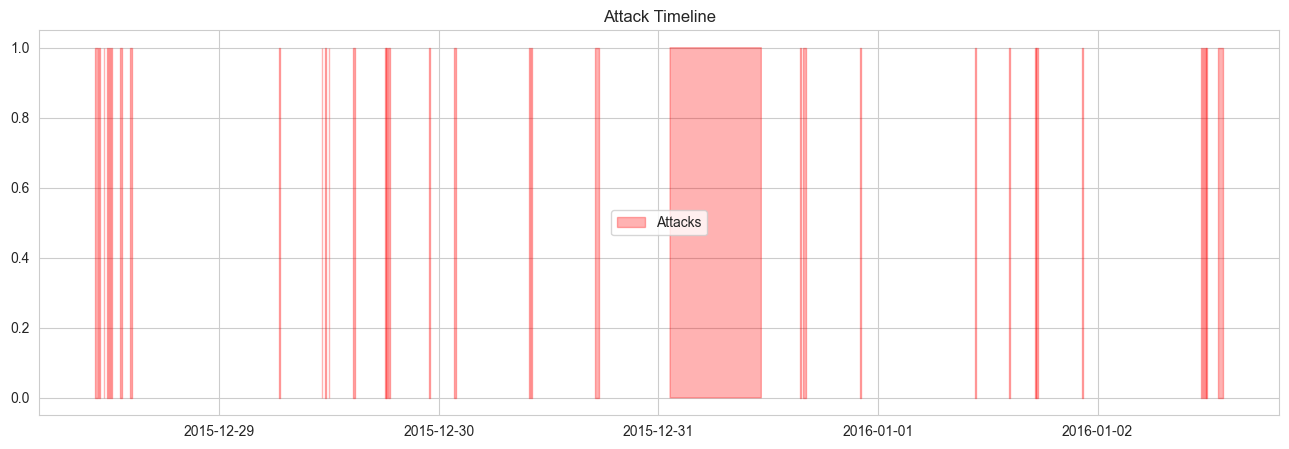

In [20]:
timeline = pd.DataFrame({
    "timestamp":ts_test,
    "label":y_test
})

timeline = timeline.sort_values("timestamp")

plt.figure(figsize=(16,5))

attack = timeline["label"]==1

plt.fill_between(
    timeline["timestamp"],
    0,
    1,
    where=attack,
    color="red",
    alpha=0.3,
    label="Attacks"
)

plt.title("Attack Timeline")

plt.legend()

plt.savefig(f"{RESULT_FIG_PATH}\\attack_timeline.png",dpi=300)

plt.show()

In [21]:
best_model = results_df.sort_values("F1",ascending=False).iloc[0]

print("\nBest Model")

print(best_model)

print("\nEvaluation Complete")

print("Figures saved in:",RESULT_FIG_PATH)

print("Statistics saved in:",RESULT_STAT_PATH)


Best Model
Model          FedAvg
Accuracy     0.999931
Precision    0.999359
Recall        0.99881
F1           0.999084
Name: 6, dtype: object

Evaluation Complete
Figures saved in: C:\Adaptive_Federated_Water_IoT\results\figures
Statistics saved in: C:\Adaptive_Federated_Water_IoT\results\statistics
